In [ ]:
import pandas as pd
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving cleaning_testing2 (1).csv to cleaning_testing2 (1).csv


In [ ]:
df = pd.read_csv("cleaning_testing2 (1).csv")

In [ ]:
print("Shape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nMatch result distribution:")
print(df["match_result"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset:
(8979, 38)

Columns:
['date', 'league', 'season', 'country', 'home_team', 'away_team', 'match_result', 'home__is_shot_on_target_sum_avg', 'home__Shooting accuracy_avg', 'home__is_goal_sum_avg', 'home__is_inside_box_sum_avg', 'home__CROSS_sum_avg', 'home__PASS_ASSIST_sum_avg', 'home__CORNER_sum_avg', 'home__fast_break_sum_avg', 'away__is_shot_on_target_sum_avg', 'away__Shooting accuracy_avg', 'away__is_goal_sum_avg', 'away__is_inside_box_sum_avg', 'away__CROSS_sum_avg', 'away__PASS_ASSIST_sum_avg', 'away__CORNER_sum_avg', 'away__fast_break_sum_avg', 'goal_diff_avg', 'shot_on_target_diff_avg', 'shooting_accuracy_diff_avg', 'inside_box_diff_avg', 'cross_diff_avg', 'pass_assist_diff_avg', 'corner_diff_avg', 'fast_break_diff_avg', 'matches_played_before', 'home_matches_played', 'away_matches_played', 'home_win_rate', 'away_win_rate', 'home_draw_rate', 'away_draw_rate']

First 5 rows:
        date league  season  country                 home_team  \
0 2011-08-13     D1    2

In [ ]:
df['matches_played_before'] = 0
team_counts = {}

home_counts = []
away_counts = []

for _, row in df.iterrows():
    home_team = row['home_team']
    away_team = row['away_team']

    home_counts.append(team_counts.get(home_team, 0))
    away_counts.append(team_counts.get(away_team, 0))

    team_counts[home_team] = team_counts.get(home_team, 0) + 1
    team_counts[away_team] = team_counts.get(away_team, 0) + 1

df['home_matches_played'] = home_counts
df['away_matches_played'] = away_counts

In [ ]:
team_stats = {}

home_win_rates = []
away_win_rates = []
home_draw_rates = []
away_draw_rates = []

for _, row in df.iterrows():
    home = row['home_team']
    away = row['away_team']
    result = row['match_result']  # 1 = home win, 0 = draw, -1 = away win

    # Get previous stats
    h_stats = team_stats.get(home, {'wins': 0, 'draws': 0, 'games': 0})
    a_stats = team_stats.get(away, {'wins': 0, 'draws': 0, 'games': 0})

    # Compute rates (before this match)
    home_win_rates.append(h_stats['wins'] / h_stats['games'] if h_stats['games'] > 0 else 0)
    away_win_rates.append(a_stats['wins'] / a_stats['games'] if a_stats['games'] > 0 else 0)

    home_draw_rates.append(h_stats['draws'] / h_stats['games'] if h_stats['games'] > 0 else 0)
    away_draw_rates.append(a_stats['draws'] / a_stats['games'] if a_stats['games'] > 0 else 0)

    # Update stats AFTER computing
    if result == 1:
        h_stats['wins'] += 1
    elif result == -1:
        a_stats['wins'] += 1
    else:
        h_stats['draws'] += 1
        a_stats['draws'] += 1

    h_stats['games'] += 1
    a_stats['games'] += 1

    team_stats[home] = h_stats
    team_stats[away] = a_stats

df['home_win_rate'] = home_win_rates
df['away_win_rate'] = away_win_rates
df['home_draw_rate'] = home_draw_rates
df['away_draw_rate'] = away_draw_rates

In [ ]:
df['season'] = pd.to_numeric(df['season'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df = df.sort_values(['season', 'date']).reset_index(drop=True)

train_df = df[df['season'].isin([2012, 2013, 2014, 2015])].copy()
test_df = df[df['season'].isin([2016, 2017])].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain seasons:")
print(train_df['season'].value_counts().sort_index())

print("\nTest seasons:")
print(test_df['season'].value_counts().sort_index())

Train shape: (6231, 39)
Test shape: (2748, 39)

Train seasons:
season
2012    1338
2013    1424
2014    1707
2015    1762
Name: count, dtype: int64

Test seasons:
season
2016    1776
2017     972
Name: count, dtype: int64


In [ ]:
for data in [train_df, test_df]:
    data['home_conf'] = data['home_matches_played'] / (data['home_matches_played'] + 5)
    data['away_conf'] = data['away_matches_played'] / (data['away_matches_played'] + 5)
    data['experience_weight'] = (data['home_conf'] + data['away_conf']) / 2

In [ ]:
for data in [train_df, test_df]:
    data["win_rate_diff"] = data["home_win_rate"] - data["away_win_rate"]
    data["draw_rate_diff"] = data["home_draw_rate"] - data["away_draw_rate"]

    # optional weighted version (recommended)
    data["win_rate_diff_w"] = data["win_rate_diff"] * data["experience_weight"]

In [ ]:
features = [
    'goal_diff_avg',
    'shot_on_target_diff_avg',
    'shooting_accuracy_diff_avg',
    'inside_box_diff_avg',
    'cross_diff_avg',
    'pass_assist_diff_avg',
    'corner_diff_avg',
    'fast_break_diff_avg'
]

for data in [train_df, test_df]:
    for f in features:
        data[f + '_w'] = data[f] * data['experience_weight']

In [ ]:
print(train_df[[
    "home_matches_played",
    "away_matches_played",
    "experience_weight",
    "goal_diff_avg",
    "goal_diff_avg_w"
]].head())

   home_matches_played  away_matches_played  experience_weight  goal_diff_avg  \
0                    0                    0                0.0           -2.0   
1                    0                    0                0.0            1.0   
2                    0                    0                0.0           -1.0   
3                    0                    0                0.0           -2.0   
4                    0                    0                0.0           -2.0   

   goal_diff_avg_w  
0             -0.0  
1              0.0  
2             -0.0  
3             -0.0  
4             -0.0  


In [ ]:
for data in [train_df, test_df]:
    data["closeness"] = (
        abs(data["goal_diff_avg_w"]) +
        abs(data["shot_on_target_diff_avg_w"]) +
        abs(data["inside_box_diff_avg_w"]) +
        abs(data["pass_assist_diff_avg_w"]))

In [ ]:
for data in [train_df, test_df]:
    data["closeness_norm"] = (
        abs(data["goal_diff_avg_w"]) / 2 +
        abs(data["shot_on_target_diff_avg_w"]) / 3 +
        abs(data["inside_box_diff_avg_w"]) / 3 +
        abs(data["pass_assist_diff_avg_w"]) / 2
    )

In [ ]:
def compute_scores(row):
    draw_score = 0
    home_score = 0
    away_score = 0

    # WIN RATE influence
    home_score += 3 if row["win_rate_diff_w"] > 0.1 else 0
    away_score += 3 if row["win_rate_diff_w"] < -0.1 else 0

    # DRAW tendency (teams that draw similarly)
    draw_score += 3 if abs(row["draw_rate_diff"]) < 0.05 else 0


    # DRAW pattern (balanced match)
    if abs(row["goal_diff_avg_w"]) < 0.3:
        draw_score += 2
    if abs(row["shot_on_target_diff_avg_w"]) < 0.5:
        draw_score += 2
    if abs(row["inside_box_diff_avg_w"]) < 0.8:
        draw_score += 1
    if abs(row["pass_assist_diff_avg_w"]) < 0.8:
        draw_score += 1

    # HOME WIN
    home_score += 2 if row["goal_diff_avg_w"] > 0.3 else 0
    home_score += 2 if row["shot_on_target_diff_avg_w"] > 0.5 else 0
    home_score += 1 if row["inside_box_diff_avg_w"] > 0.8 else 0
    home_score += 1 if row["pass_assist_diff_avg_w"] > 0.8 else 0

    # AWAY WIN
    away_score += 2 if row["goal_diff_avg_w"] < -0.3 else 0
    away_score += 2 if row["shot_on_target_diff_avg_w"] < -0.4 else 0
    away_score += 1 if row["inside_box_diff_avg_w"] < -0.4 else 0
    away_score += 1 if row["pass_assist_diff_avg_w"] < -0.4 else 0

    return draw_score, home_score, away_score

In [ ]:
def final_prediction(row):
    draw_score, home_score, away_score = compute_scores(row)

    # Strong draw condition using closeness
    if row["closeness_norm"] < 1.1:
        return 0

    if (abs(row["shot_on_target_diff_avg_w"]) < 0.5 and abs(row["inside_box_diff_avg_w"]) < 0.8):
        return 0

    # Second draw condition
    if (abs(row["goal_diff_avg_w"]) < 0.25 and abs(row["shot_on_target_diff_avg_w"]) < 0.8):
        return 0

    # Strong home dominance override
    if row["goal_diff_avg_w"] > 0.6 and row["shot_on_target_diff_avg_w"] > 1.0:
        return 1

    # Strong away dominance override
    if row["goal_diff_avg_w"] < -0.6 and row["shot_on_target_diff_avg_w"] < -1.0:
        return -1

    if draw_score >= 5 and draw_score > home_score and draw_score > away_score:
        return 0
    elif home_score >= away_score:
        return 1
    else:
        return -1

In [ ]:
test_df["prediction"] = test_df.apply(final_prediction, axis=1)
print(test_df["prediction"].value_counts())


prediction
 0    948
-1    941
 1    859
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_df["match_result"], test_df["prediction"]))

              precision    recall  f1-score   support

        -1.0       0.42      0.51      0.46       781
         0.0       0.28      0.38      0.32       697
         1.0       0.63      0.42      0.51      1270

    accuracy                           0.44      2748
   macro avg       0.44      0.44      0.43      2748
weighted avg       0.48      0.44      0.45      2748



In [ ]:
print(test_df["prediction"].value_counts())
print(test_df["prediction"].value_counts(normalize=True))

prediction
 0    949
-1    943
 1    856
Name: count, dtype: int64
prediction
 0    0.345342
-1    0.343159
 1    0.311499
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
feature_cols = [
    "goal_diff_avg_w",
    "shot_on_target_diff_avg_w",
    "inside_box_diff_avg_w",
    "pass_assist_diff_avg_w"
]

plot_df = train_df.groupby("match_result")[feature_cols].mean().copy()

plot_df.index = plot_df.index.map({
    -1.0: "Away Win",
     0.0: "Draw",
     1.0: "Home Win"
})

plot_df = plot_df.loc[["Away Win", "Draw", "Home Win"]]
print(plot_df)

              goal_diff_avg_w  shot_on_target_diff_avg_w  \
match_result                                               
Away Win            -0.314677                  -0.686701   
Draw                -0.074487                  -0.156093   
Home Win             0.163745                   0.316928   

              inside_box_diff_avg_w  pass_assist_diff_avg_w  
match_result                                                 
Away Win                  -0.946882               -0.771811  
Draw                      -0.300304               -0.145132  
Home Win                   0.407466                0.382055  


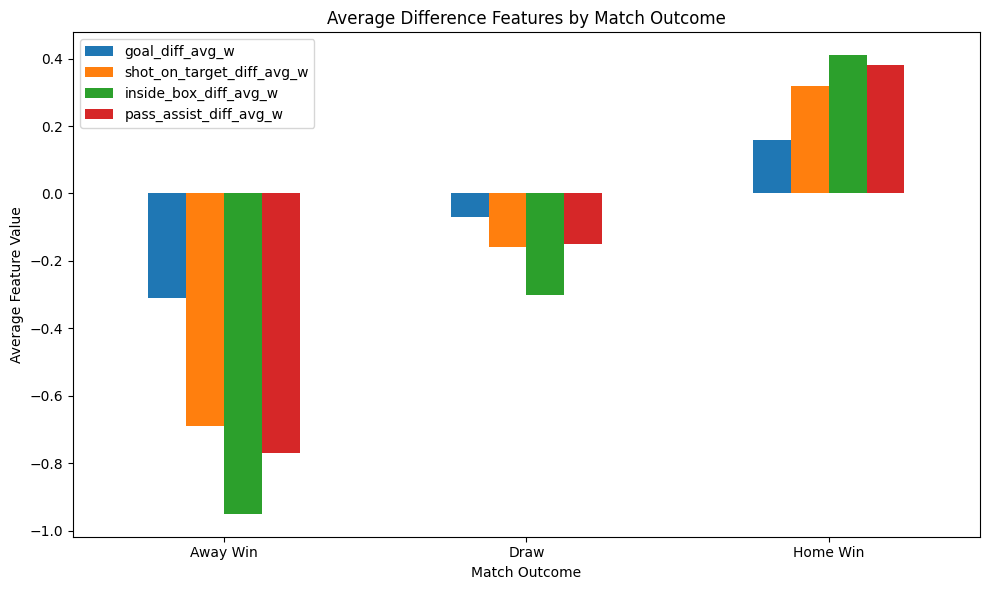

In [ ]:
feature_cols = [
    "goal_diff_avg_w",
    "shot_on_target_diff_avg_w",
    "inside_box_diff_avg_w",
    "pass_assist_diff_avg_w"
]

plot_df = train_df.groupby("match_result")[feature_cols].mean().round(2).copy()

plot_df.index = plot_df.index.map({
    -1.0: "Away Win",
     0.0: "Draw",
     1.0: "Home Win"
})

plot_df = plot_df.loc[["Away Win", "Draw", "Home Win"]]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Average Difference Features by Match Outcome")
plt.xlabel("Match Outcome")
plt.ylabel("Average Feature Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()